**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


**LOAD THE DATASET**

In [2]:
df = pd.read_csv("/content/student_performance_dataset_500.csv")
df.head()

,Student_ID,Gender,Age,Grade_Level,Attendance (%),Hours_Studied_Weekly,Parental_Education_Level,Household_Income,Previous_Year_Grade,Participation_in_Extracurriculars,Health_Status,Final_Grade
0,S001,Female,18,11th,79,7,Bachelor's,Low,A,No,Average,C
1,S002,Female,17,9th,92,13,Bachelor's,Low,C,Yes,Average,B
2,S003,Male,16,11th,71,6,Master's,High,C,No,Average,C
3,S004,Female,16,11th,74,6,Master's,Low,B,Yes,Poor,B
4,S005,Female,14,12th,100,17,Master's,High,A,No,Average,D


**DATA** **PREPROCESSING**

In [3]:
label_encoders = {}
for column in ["Gender", "Grade_Level", "Parental_Education_Level", "Household_Income", "Previous_Year_Grade", "Participation_in_Extracurriculars", "Health_Status", "Final_Grade"]:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])


**SPLIT FEATURES AND TARGET**

In [4]:

X = df.drop(["Final_Grade", "Student_ID"], axis=1)
y = df["Final_Grade"]  # Target


**TRAIN TEST SPLIT**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



**FEATURE SCALING**

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**MODEL BUILDING**

In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

**MODEL EVALUATION**

In [8]:
y_pred = model.predict(X_test)


**EVALUATE THE MODEL**

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoders["Final_Grade"].classes_))


Accuracy: 20.00%
Classification Report:
              precision    recall  f1-score   support

           A       0.14      0.13      0.14        23
           B       0.22      0.47      0.30        17
           C       0.38      0.13      0.19        23
           D       0.17      0.31      0.22        13
           F       0.20      0.08      0.12        24

    accuracy                           0.20       100
   macro avg       0.22      0.22      0.19       100
weighted avg       0.23      0.20      0.18       100



In [10]:
# Checking unique classes in the target variable
unique_classes = y.unique()
print("Unique classes in the dataset:", unique_classes)



Unique classes in the dataset: [2 1 3 4 0]


In [11]:
# Example to remap or filter unexpected labels
y = y.replace({4: 3})  # Example: Map any '4' class label to '3'


In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Setting up the XGBoost model with regularization
model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(unique_classes),  # Ensure the correct number of classes
    max_depth=3,  # Reduce the depth to prevent overfitting
    n_estimators=100,
    learning_rate=0.1,
    early_stopping_rounds=10,
    random_state=42
)

# Fit the model with early stopping
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.29
Classification Report:
               precision    recall  f1-score   support

           0       0.20      0.04      0.07        23
           1       0.08      0.06      0.07        17
           2       0.29      0.09      0.13        23
           3       0.33      0.68      0.44        37

    accuracy                           0.29       100
   macro avg       0.22      0.22      0.18       100
weighted avg       0.25      0.29      0.22       100



In [13]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of samples
num_samples = 1000  # Increased to 1000 for better learning

# Generate features
student_ids = [f"S{str(i).zfill(4)}" for i in range(1, num_samples + 1)]
genders = np.random.choice(["Male", "Female"], num_samples)
ages = np.random.randint(14, 19, num_samples)
grade_levels = np.random.choice(["9th", "10th", "11th", "12th"], num_samples)
attendance = np.random.randint(60, 101, num_samples)
study_hours = np.random.randint(5, 25, num_samples)
parental_education = np.random.choice(["High School", "Bachelor's", "Master's"], num_samples)
household_income = np.random.choice(["Low", "Medium", "High"], num_samples)
previous_grade = np.random.choice(["A", "B", "C", "D"], num_samples)
extracurriculars = np.random.choice(["Yes", "No"], num_samples)
health_status = np.random.choice(["Good", "Average", "Poor"], num_samples)

# Initialize Final_Grade with default 'C'
final_grades = ['C'] * num_samples

# Define rules to assign Final_Grade based on features
for i in range(num_samples):
    score = 0
    # Higher attendance
    if attendance[i] > 90:
        score += 1
    # More study hours
    if study_hours[i] > 15:
        score += 1
    # Higher parental education
    if parental_education[i] in ["Bachelor's", "Master's"]:
        score += 1
    # Higher household income
    if household_income[i] == "High":
        score += 1
    # Previous year grade
    if previous_grade[i] in ["A", "B"]:
        score += 1
    # Participation in extracurriculars
    if extracurriculars[i] == "Yes":
        score += 1
    # Good health status
    if health_status[i] == "Good":
        score += 1

    # Assign Final_Grade based on the score
    if score >= 5:
        final_grades[i] = 'A'
    elif score == 4:
        final_grades[i] = 'B'
    elif score == 3:
        final_grades[i] = 'C'
    elif score == 2:
        final_grades[i] = 'D'
    else:
        final_grades[i] = 'F'

# Create the DataFrame
data = {
    "Student_ID": student_ids,
    "Gender": genders,
    "Age": ages,
    "Grade_Level": grade_levels,
    "Attendance (%)": attendance,
    "Hours_Studied_Weekly": study_hours,
    "Parental_Education_Level": parental_education,
    "Household_Income": household_income,
    "Previous_Year_Grade": previous_grade,
    "Participation_in_Extracurriculars": extracurriculars,
    "Health_Status": health_status,
    "Final_Grade": final_grades
}

df = pd.DataFrame(data)

# Display the first few rows
print(df.head())


  Student_ID  Gender  Age Grade_Level  Attendance (%)  Hours_Studied_Weekly  \
0      S0001    Male   14        10th              72                    24   
1      S0002  Female   14        11th              67                    24   
2      S0003    Male   14        10th              82                    22   
3      S0004    Male   18        10th              60                    18   
4      S0005    Male   17        11th              83                    22   

  Parental_Education_Level Household_Income Previous_Year_Grade  \
0                 Master's              Low                   A   
1              High School              Low                   C   
2                 Master's              Low                   D   
3                 Master's           Medium                   D   
4              High School           Medium                   B   

  Participation_in_Extracurriculars Health_Status Final_Grade  
0                               Yes          Poor         

In [14]:
# Save to CSV
df.to_csv("student_performance_dataset_improved.csv", index=False)

# To load the dataset later
df = pd.read_csv("student_performance_dataset_improved.csv")
df.head()


,Student_ID,Gender,Age,Grade_Level,Attendance (%),Hours_Studied_Weekly,Parental_Education_Level,Household_Income,Previous_Year_Grade,Participation_in_Extracurriculars,Health_Status,Final_Grade
0,S0001,Male,14,10th,72,24,Master's,Low,A,Yes,Poor,B
1,S0002,Female,14,11th,67,24,High School,Low,C,Yes,Poor,D
2,S0003,Male,14,10th,82,22,Master's,Low,D,No,Good,C
3,S0004,Male,18,10th,60,18,Master's,Medium,D,Yes,Poor,C
4,S0005,Male,17,11th,83,22,High School,Medium,B,No,Average,D


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# Load the improved dataset
df = pd.read_csv("student_performance_dataset_improved.csv")

# Encode categorical variables
label_encoders = {}
categorical_columns = ["Gender", "Grade_Level", "Parental_Education_Level",
                       "Household_Income", "Previous_Year_Grade",
                       "Participation_in_Extracurriculars", "Health_Status", "Final_Grade"]

for column in categorical_columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Separate features and target
X = df.drop(["Final_Grade", "Student_ID"], axis=1)
y = df["Final_Grade"]

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define classifiers
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Create Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf)],
    voting='soft'
)

# Train the ensemble model
voting_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred = voting_clf.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred,
                                                        target_names=label_encoders["Final_Grade"].classes_))


Accuracy: 0.69
Classification Report:
               precision    recall  f1-score   support

           A       0.78      0.97      0.86        59
           B       0.61      0.65      0.63        55
           C       0.57      0.42      0.48        65
           D       0.61      0.64      0.63        59
           F       0.87      0.82      0.84        55

    accuracy                           0.69       293
   macro avg       0.69      0.70      0.69       293
weighted avg       0.69      0.69      0.68       293



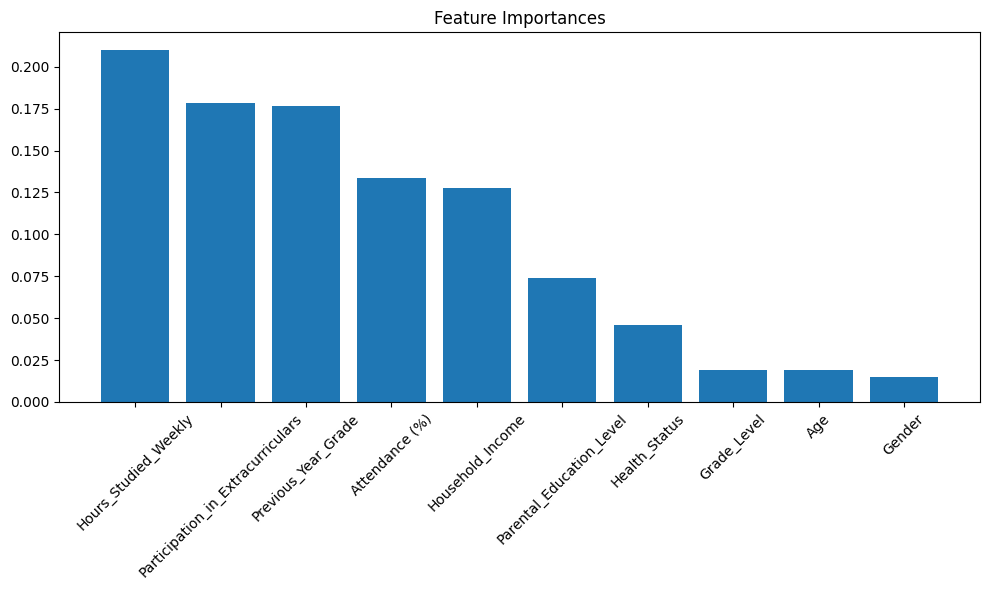

In [16]:
import matplotlib.pyplot as plt

# Fit the Random Forest classifier separately
# Use X_train_scaled and y_train, which were created after SMOTE oversampling
rf_clf.fit(X_train_scaled, y_train)

# Feature importance from Random Forest
feature_importances = rf_clf.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X.shape[1]), features[indices], rotation=45)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

# Example for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                       cv=5, scoring='accuracy')
grid_rf.fit(X_train_scaled, y_train)

print(f"Best parameters for Random Forest: {grid_rf.best_params_}")
print(f"Best cross-validation accuracy: {grid_rf.best_score_:.2f}")

# Use the best estimator
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf,
                                                                    target_names=label_encoders["Final_Grade"].classes_))


Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.72
Random Forest Classification Report:
               precision    recall  f1-score   support

           A       0.81      0.98      0.89        59
           B       0.60      0.62      0.61        55
           C       0.68      0.49      0.57        65
           D       0.77      0.73      0.75        59
           F       0.87      0.96      0.91        55

    accuracy                           0.75       293
   macro avg       0.74      0.76      0.75       293
weighted avg       0.74      0.75      0.74       293



In [18]:
scores = cross_val_score(voting_clf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validated Accuracy: {np.mean(scores):.2f} ± {np.std(scores):.2f}")


Cross-Validated Accuracy: 0.72 ± 0.01


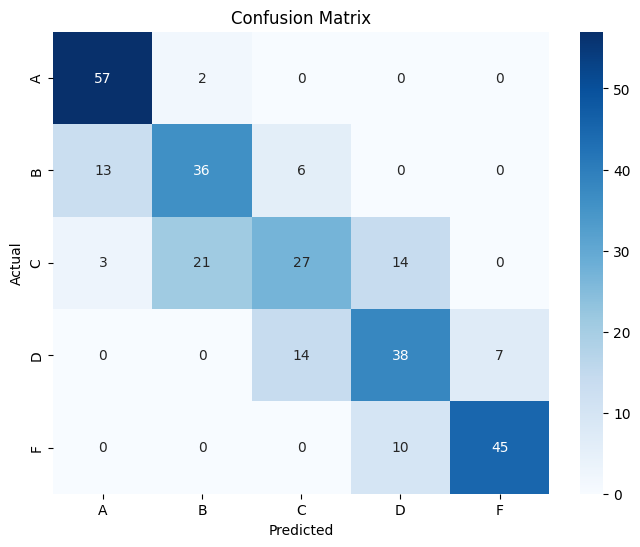

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoders["Final_Grade"].classes_,
            yticklabels=label_encoders["Final_Grade"].classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Define a broader parameter grid for RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Set up RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(estimator=rf_model,
                                   param_distributions=param_grid,
                                   n_iter=50, # Number of different combinations to try
                                   cv=5,      # 5-fold cross-validation
                                   verbose=1,
                                   n_jobs=-1,
                                   random_state=42)

# Fit the RandomizedSearchCV on training data
random_search.fit(X_train, y_train)

# Get the best parameters and accuracy from RandomizedSearchCV
best_rf_model = random_search.best_estimator_
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation accuracy: ", random_search.best_score_)

# Predict and evaluate on the test set
y_pred = best_rf_model.predict(X_test)
print("Test Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:  {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best cross-validation accuracy:  0.7372176759410802
Test Accuracy:  0.7474402730375427
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89        59
           1       0.64      0.64      0.64        55
           2       0.65      0.51      0.57        65
           3       0.75      0.69      0.72        59
           4       0.87      0.95      0.90        55

    accuracy                           0.75       293
   macro avg       0.74      0.75      0.74       293
weighted avg       0.74      0.75      0.74       293



In [21]:
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # Import necessary classifiers

# Define your base estimators
base_estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    # ... add other base estimators as needed
]

meta_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, solver='saga'))

stacking_clf = StackingClassifier(estimators=base_estimators, final_estimator=meta_model, cv=5)

stacking_clf.fit(X_train, y_train)
y_pred = stacking_clf.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Adjusted Stacking Classifier Accuracy: {accuracy:.2f}")
print("Adjusted Classification Report:\n", classification_report(y_test, y_pred))

Adjusted Stacking Classifier Accuracy: 0.85
Adjusted Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92        59
           1       0.76      0.76      0.76        55
           2       0.82      0.75      0.78        65
           3       0.86      0.81      0.83        59
           4       0.91      0.95      0.93        55

    accuracy                           0.85       293
   macro avg       0.85      0.85      0.85       293
weighted avg       0.84      0.85      0.84       293

